<p class="mlx-kicker">Part III &middot; Training recipe &middot; Chapter 10</p>

# 10. Learning-rate schedule: from step decay to warmup-stable-decay

<dl class="mlx-meta"><div><dt>Level</dt><dd>Intermediate</dd></div><div><dt>Reading</dt><dd>about 20 min</dd></div><div><dt>Hands-on</dt><dd>about 9 min on a laptop CPU</dd></div><div><dt>You should know</dt><dd>Chapter 1, chapter 9 (Adam), gradient descent</dd></div></dl>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daiyip/transformer-explained/blob/main/chapters/10-lr-schedule/index.ipynb)

![Three generations of learning-rate schedule, drawn as learning rate against training step. Each column highlights what is new: cutting the rate at milestones, a warmup followed by a smooth decay, and a long flat phase with a short decay that can be branched off from any checkpoint.](figures/schedule-lineage.svg)

## What changed, and why it works

The learning rate is the one number that sets how far every update moves the weights. A schedule changes it over the course of training. It costs nothing to compute, yet on our small model the choice of schedule moves the final loss by 0.08 nats, more than many of the architecture changes in Part II. Each generation in Figure 10.1 changes the *shape* of the curve, never the peak.

<div class="mlx-why">
<section class="mlx-why__card mlx-why__card--1"><p class="mlx-why__n">1 &middot; Step decay</p><h3>Cut the rate at milestones</h3><p><b>What changed.</b> Instead of one rate for the whole run, the rate is divided by 10 at a few hand-picked points, for example at 50% and 75% of training.</p><p><b>Why it works.</b> Each gradient comes from a small random batch, so it is noisy. With a constant rate the weights keep bouncing around the minimum in a cloud whose size grows with the rate, and the loss stalls on a floor proportional to it. A large rate travels fast; a small one settles low. Cutting the rate gets both, one after the other.</p><p class="mlx-why__run">Our runs, 500 steps: constant 1.869, step decay 1.843</p></section>
<section class="mlx-why__card mlx-why__card--2"><p class="mlx-why__n">2 &middot; Warmup + cosine</p><h3>Ramp up first, then decay smoothly</h3><p><b>What changed.</b> The rate starts near zero and rises linearly over the first steps (warmup), then follows half a cosine wave down to near zero, with no milestones to tune.</p><p><b>Why it works.</b> On its first update Adam divides the gradient by its own size, so every weight moves by the full rate, even weights whose gradient is pure noise. With small initial weights that can rewrite the network in a few steps. Warmup keeps those steps small until Adam's statistics settle. The cosine then spends long stretches at both high and low rates.</p><p class="mlx-why__run">Our runs: at peak 0.1, 2.839 without warmup, 2.425 with it; cosine 1.799</p></section>
<section class="mlx-why__card mlx-why__card--3"><p class="mlx-why__n">3 &middot; Warmup-stable-decay</p><h3>Hold flat, decay only at the end</h3><p><b>What changed.</b> After warmup the rate stays at its peak for most of the run, then falls to zero over the last 10 to 20% of steps.</p><p><b>Why it works.</b> Most of the benefit of decay comes from the final drop, which removes the noise cloud; it does not need to start early. Because the flat phase does not depend on the run's length, a short decay can be branched off any of its checkpoints to get a finished model. Schedule-free training goes further and replaces the decay with a running average of the weights.</p><p class="mlx-why__run">Our runs: WSD 1.790 vs cosine 1.799; a 50-step branch gives 1.925 at 250 steps vs 1.956 for a fresh cosine run</p></section>
</div>

Read left to right, the pressure moves from *settling into a minimum*, to *surviving the first steps of a Transformer trained with Adam*, to *not having to know the training length in advance*. The steps below rebuild each schedule and test it on the same model.

## Evolution path

| Year | Step | Level | What changed |
| --- | --- | --- | --- |
| 1951-2000s | Decaying step sizes for SGD | minor | theory says the step must shrink for noisy gradients to converge |
| 2012-2016 | Step decay | **major** | hand-picked milestones divide the rate by 10 (AlexNet, ResNet) |
| 2016 | Cosine annealing (SGDR) | **major** | one smooth curve replaces the milestones |
| 2017 | Linear warmup | **major** | ramp up over the first steps (Goyal et al.; the Transformer's inverse-sqrt schedule) |
| 2019-2020 | Warmup explained | minor | RAdam and pre-norm analyses link warmup to Adam's early statistics and to Post-LN |
| 2024 | Warmup-stable-decay | **major** | constant rate for most of the run, short decay at the end (MiniCPM) |
| 2024 | Schedule-free | minor | no decay at all: average the weights instead (Defazio et al.) |

## The lineage post-mortem: what drove each replacement?

| Replacement | Pressure that drove it | What it bought |
| --- | --- | --- |
| constant to step decay | the loss stalls on a noise floor set by the rate | fast early progress and a low final loss |
| step decay to cosine | milestones had to be tuned by hand for every task | one smooth curve with no extra knobs |
| no warmup to warmup | Adam's oversized first steps blew up Transformer training | stable starts and a wider range of usable peak rates |
| cosine to warmup-stable-decay | cosine must know the total length before training starts | finished models at any length from one run |
| decay to schedule-free | even WSD must decide when to stop before decaying | no decay phase: the averaged weights are always usable |

Every replacement kept the same peak learning rate and changed only *when* the rate is high. The early changes were about the optimization itself. The later ones were about the economics of training: how many runs you need, and how late you can decide how long to train. That shift tracks the move from ImageNet experiments that fit on one machine to LLM pretraining runs that cost millions.

**Still open:** why warmup helps is still debated: Adam's early statistics, Post-LN gradient scales, and the network moving to flatter regions that tolerate a larger rate are all supported by some evidence. **[likely]** It is also unclear exactly why a short final decay recovers almost all of what a long cosine gives, and whether schedule-free averaging matches a tuned decay at the largest scales. **[speculative]**

## Diverged branches

The evolution path follows the line today's models inherited. At a few points the field split instead: two camps made different bets on the same problem, and sometimes both bets are still alive. Each tab below is one such fork, with the two branches, why they split, and how it has played out so far.

<div class="mlx-why mlx-forks" data-label="Forks in this lineage">
<section class="mlx-why__card mlx-why__card--1 mlx-fork"><p class="mlx-why__n">Fork 1 &middot; 2017-2022</p><h3>Inverse square root, or cosine?</h3><div class="mlx-fork__sides"><div class="mlx-fork__side"><p class="mlx-fork__name">Inverse square root <span class="mlx-fork__state mlx-fork__state--niche">niche</span></p><p>Warm up, then decay as <code>1/&radic;step</code>. It never reaches zero and never needs to know when training ends.</p><p class="mlx-fork__who">the original Transformer, T5</p></div><span class="mlx-fork__vs" aria-hidden="true">vs</span><div class="mlx-fork__side"><p class="mlx-fork__name">Cosine <span class="mlx-fork__state mlx-fork__state--main">mainline</span></p><p>One smooth curve from the peak to a small floor at a known final step.</p><p class="mlx-fork__who">GPT-3, Chinchilla, LLaMA</p></div></div><p><b>Why they split.</b> The inverse square root fits open-ended training; cosine needs the length fixed in advance but anneals fully at the end.</p><p><b>How it played out.</b> Cosine took over LLM pretraining once runs were planned against a fixed token budget, and Hoffmann et al. (2022) showed its cycle should match the training length or the loss suffers. The wish for a schedule that does not need to know the end came back as warmup-stable-decay (step 4). <strong>[established]</strong></p></section>
<section class="mlx-why__card mlx-why__card--2 mlx-fork"><p class="mlx-why__n">Fork 2 &middot; 2022-2025</p><h3>Decay to 10% of the peak, or all the way to zero?</h3><div class="mlx-fork__sides"><div class="mlx-fork__side"><p class="mlx-fork__name">Decay to 10% <span class="mlx-fork__state mlx-fork__state--main">mainline</span></p><p>Cosine down to a tenth of the peak rate, the Chinchilla and LLaMA default.</p><p class="mlx-fork__who">GPT-3, Chinchilla, LLaMA</p></div><span class="mlx-fork__vs" aria-hidden="true">vs</span><div class="mlx-fork__side"><p class="mlx-fork__name">Linear decay to zero <span class="mlx-fork__state mlx-fork__state--rival">contender</span></p><p>A straight line from the peak down to exactly zero.</p><p class="mlx-fork__who">Bergsma et al. (2025)</p></div></div><p><b>Why they split.</b> The last stretch of training at a low rate acts like averaging over recent updates. Going all the way to zero averages away more of the gradient noise.</p><p><b>How it played out.</b> Bergsma et al. (2025) find linear decay to zero beats cosine to 10% at compute-optimal budgets, with the gain growing as models see more tokens per parameter. It is a recent result, not yet the standard. <strong>[likely]</strong></p></section>
<section class="mlx-why__card mlx-why__card--3 mlx-fork"><p class="mlx-why__n">Fork 3 &middot; 2018-2024</p><h3>Decay the rate, or average the weights?</h3><div class="mlx-fork__sides"><div class="mlx-fork__side"><p class="mlx-fork__name">Decay <span class="mlx-fork__state mlx-fork__state--main">mainline</span></p><p>Shrink the step size so the weights settle.</p><p class="mlx-fork__who">nearly every training run</p></div><span class="mlx-fork__vs" aria-hidden="true">vs</span><div class="mlx-fork__side"><p class="mlx-fork__name">Averaging <span class="mlx-fork__state mlx-fork__state--rival">contender</span></p><p>Keep the rate high and average the weights instead: SWA averages along the trajectory, schedule-free methods (step 5) build averaging into the optimizer.</p><p class="mlx-fork__who">SWA, schedule-free AdamW, EMA checkpoints</p></div></div><p><b>Why they split.</b> Decaying the rate and averaging the iterates both cancel the noise of stochastic gradients. Averaging does not need to know when training ends.</p><p><b>How it played out.</b> Schedule-free AdamW won the self-tuning track of the AlgoPerf benchmark. In LLM pretraining averaging is used alongside decay more than instead of it; Llama 3, for example, averaged checkpoints during its final annealing. <strong>[likely]</strong></p></section>
</div>

## Run it yourself

The steps share this setup: the TinyShakespeare data, a small version of the chapter 1 model (width 64, 4 blocks, about 200,000 parameters), a function that builds each schedule, and a training loop that sets the learning rate before every update. Every run uses the same seed and the same data order, so the schedule is the only thing that changes. The whole notebook runs in about 9 minutes on one CPU thread.

In [1]:
# Setup: works from a checkout of the repo and on Google Colab.
import pathlib, subprocess, sys

try:
    import mlexp
except ImportError:
    root = pathlib.Path.cwd().resolve().parents[1]
    if (root / "mlexp").is_dir():
        sys.path.insert(0, str(root))
    else:  # Colab: install the shared helpers from GitHub
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/daiyip/transformer-explained"], check=True)
    import mlexp

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
mlexp.setup_style()
device_note = "GPU available" if torch.cuda.is_available() else "running on CPU"
print(f"torch {torch.__version__}, {device_note}")

torch 2.14.1+cu130, running on CPU


In [2]:
import copy, math, time
from mlexp.transformer import TransformerLM

torch.set_num_threads(1)  # small models run fastest on one thread; raise it if you like
tok, train_ids, val_ids = mlexp.load_char_corpus()
t_start = time.time()

In [3]:
def make_schedule(kind, peak, steps, warmup=50, decay_frac=0.2):
    """Return lr(step) for one of this chapter's schedules. Every one starts with a linear warmup."""
    def lr(s):
        if s < warmup:
            return peak * (s + 1) / warmup
        if kind == "constant":
            return peak
        if kind == "step":  # divide by 10 at 50% and again at 75% of training
            return peak * 0.1 ** ((s >= steps // 2) + (s >= 3 * steps // 4))
        if kind == "cosine":  # half a cosine wave from the peak down to zero
            progress = (s - warmup) / max(1, steps - warmup)
            return peak * 0.5 * (1 + math.cos(math.pi * progress))
        if kind == "wsd":  # flat until the last decay_frac of training, then linear to zero
            decay_start = int(steps * (1 - decay_frac))
            return peak if s < decay_start else peak * (steps - s) / (steps - decay_start)
        if kind == "inv_sqrt":  # the original Transformer schedule
            return peak * math.sqrt(warmup / (s + 1))
        raise ValueError(kind)
    return lr

In [4]:
VAL = [mlexp.get_batch(val_ids, 32, 64, torch.Generator().manual_seed(100 + i)) for i in range(8)]


@torch.no_grad()
def val_loss(model):
    model.eval()
    loss = sum(model(x, y)[1].item() for x, y in VAL) / len(VAL)
    model.train()
    return loss


def train(lr_at, steps, beta2=0.95, resume=None, save_at=(), eval_every=50, track=False):
    """Train the chapter 1 model with AdamW, setting the learning rate to lr_at(step) before every update.

    resume: a checkpoint saved by an earlier run (model, optimizer and data-order state), to branch from.
    track:  also record how far each update moves the weights, relative to their size.
    """
    torch.manual_seed(0)
    model = TransformerLM(tok.vocab_size, dim=64, n_layers=4, n_heads=4)
    opt = torch.optim.AdamW(model.parameters(), lr=0.0, betas=(0.9, beta2), weight_decay=0.1)
    gen = torch.Generator().manual_seed(0)
    first = 0
    if resume is not None:
        model.load_state_dict(resume["model"]); opt.load_state_dict(resume["opt"])
        gen.set_state(resume["gen"]); first = resume["step"]
    mats = [p for n, p in model.named_parameters() if p.dim() == 2 and "blocks" in n]
    h = {"step": [], "val": [], "train": [], "lr": [], "rel_update": [], "adam_ratio": [], "ckpt": {}}
    for s in range(first, steps + 1):
        if s in save_at:
            h["ckpt"][s] = {"model": copy.deepcopy(model.state_dict()), "opt": copy.deepcopy(opt.state_dict()),
                            "gen": gen.get_state(), "step": s}
        if s % eval_every == 0 or s == steps:
            h["step"].append(s)
            h["val"].append(val_loss(model))
        if s == steps:
            break
        for group in opt.param_groups:
            group["lr"] = lr_at(s)
        x, y = mlexp.get_batch(train_ids, 32, 64, gen)
        _, loss = model(x, y)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        before = [p.detach().clone() for p in mats] if track else None
        opt.step()
        h["train"].append(loss.item())
        h["lr"].append(lr_at(s))
        if track:
            moved = sum((p.detach() - b).pow(2).sum() for p, b in zip(mats, before)).sqrt()
            h["rel_update"].append((moved / sum(b.pow(2).sum() for b in before).sqrt()).item())
            # Adam's per-coordinate step, before the learning rate: m_hat / sqrt(v_hat)
            ratios = []
            for p in mats:
                st = opt.state[p]
                t = st["step"].item()
                m_hat = st["exp_avg"] / (1 - 0.9 ** t)
                v_hat = st["exp_avg_sq"] / (1 - beta2 ** t)
                ratios.append((m_hat / (v_hat.sqrt() + 1e-8)).pow(2).mean().sqrt().item())
            h["adam_ratio"].append(sum(ratios) / len(ratios))
    return h


def smooth(xs, k=20):
    """Running mean, to make noisy per-step training losses readable."""
    xs = np.asarray(xs)
    return np.convolve(xs, np.ones(k) / k, mode="valid")

### Step 1 (minor): constant rate, then step decay

#### The idea

The learning rate `\(\eta\)` sets how far each update moves the weights. Early in training the weights are far from any good solution, so big steps help. Late in training they are close, and big steps hurt, because each gradient is computed on a small random batch and so contains noise. With a constant rate, the weights never settle: they keep bouncing around the minimum in a cloud whose size is set by `\(\eta\)`. Shrinking the rate shrinks the cloud.

The classic fix was **step decay**: train at a constant rate until progress stalls, then divide the rate by 10, and repeat. AlexNet (Krizhevsky et al., 2012) did this by hand whenever the validation error stopped improving. ResNet (He et al., 2016) fixed the milestones in advance: divide by 10 at 32,000 and 48,000 iterations. The loss curves of that era have a familiar staircase shape, with a sudden drop at every cut.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: the learning rate sets the noise floor</p><div class="mlx-eq">$$w_{t+1} = w_t - \eta\,(h\,w_t + \xi_t) \quad\Longrightarrow\quad \mathbb{E}\big[f(w_\infty)\big] = \frac{\eta\,\sigma^2}{2\,(2 - \eta h)} \approx \frac{\eta\,\sigma^2}{4}$$</div><p class="mlx-eq__where">SGD on one direction of a quadratic \(f(w) = \tfrac{1}{2} h w^2\), with gradient noise \(\xi_t\) of variance \(\sigma^2\). The loss stops falling at a floor proportional to \(\eta\), whatever the curvature \(h\). Halving the rate halves the floor, but in flat directions (small \(h\)) it also halves the speed.</p></div>

We can watch this on a noisy quadratic with 20 directions of different steepness: a cheap stand-in for a network's loss surface near a minimum.

constant, lr 0.5                 loss at step 2000: 3.536   at the end: 2.5738
constant, lr 0.05                loss at step 2000: 0.401   at the end: 0.2516
step decay 0.5 -> 0.05 -> 0.005  loss at step 2000: 2.127   at the end: 0.0960
predicted floor for lr 0.5: 2.50, for lr 0.05: 0.250


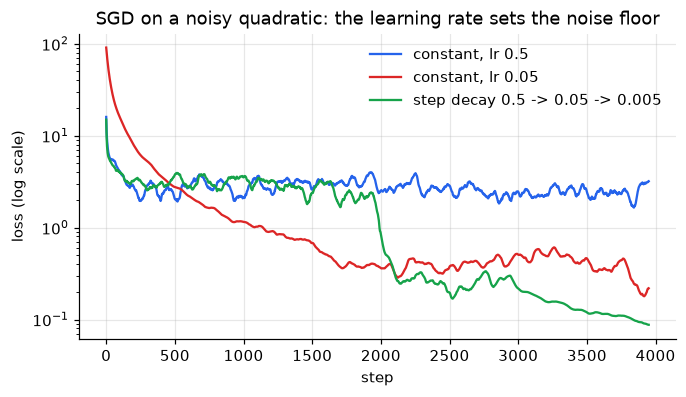

In [5]:
# A noisy quadratic: SGD on f(w) = 0.5 * sum(h_i * w_i^2), with Gaussian noise added to every gradient.
rng = np.random.default_rng(0)
h = np.logspace(-2, 0, 20)  # curvatures from 0.01 to 1: some directions are steep, most are flat
sigma, steps = 1.0, 4000


def sgd_quadratic(lr_at):
    w = np.full_like(h, 10.0)
    losses = []
    for s in range(steps):
        grad = h * w + sigma * rng.standard_normal(h.shape)
        w = w - lr_at(s) * grad
        losses.append(0.5 * np.sum(h * w ** 2))
    return np.array(losses)


toy = {
    "constant, lr 0.5": sgd_quadratic(lambda s: 0.5),
    "constant, lr 0.05": sgd_quadratic(lambda s: 0.05),
    "step decay 0.5 -> 0.05 -> 0.005": sgd_quadratic(lambda s: 0.5 * 0.1 ** ((s >= steps // 2) + (s >= 3 * steps // 4))),
}
fig, ax = plt.subplots(figsize=(7, 3.6))
for name, l in toy.items():
    ax.semilogy(smooth(l, 50), label=name)
ax.set(xlabel="step", ylabel="loss (log scale)", title="SGD on a noisy quadratic: the learning rate sets the noise floor")
ax.legend(frameon=False)
for name, l in toy.items():
    print(f"{name:32s} loss at step 2000: {l[1950:2000].mean():.3f}   at the end: {l[-200:].mean():.4f}")
print(f"predicted floor for lr 0.5: {20 * 0.5 * sigma**2 / 4:.2f}, for lr 0.05: {20 * 0.05 * sigma**2 / 4:.3f}")

The loss at a constant rate stalls exactly where the equation predicts: about 2.57 for rate 0.5 (predicted 2.50) and 0.25 for rate 0.05 (predicted 0.25). The high rate gets there in a few hundred steps; the low one needs about 2,000. Step decay starts like the high rate, and each cut by 10 drops the loss toward a new, lower floor. In this run it ends at 0.096, below both constant rates, but that is the lucky seed: in the other two seeds we ran it ended at 0.24 and 0.25, level with the constant rate 0.05, probably because the last phase at rate 0.005 is too short to reach its own floor. **[established]** for the floors; our step-decay end point is noisy.

Here is every schedule in this chapter, built by the `make_schedule` function above. The inverse square-root curve is the original Transformer's; we draw it for reference but do not train with it.

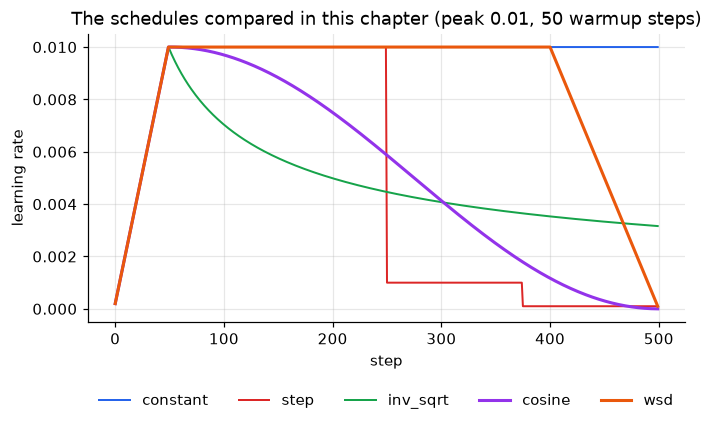

In [6]:
budget = 500
fig, ax = plt.subplots(figsize=(7, 3.4))
for kind in ["constant", "step", "inv_sqrt", "cosine", "wsd"]:
    lr = make_schedule(kind, 1e-2, budget)
    ax.plot([lr(s) for s in range(budget)], label=kind, lw=2 if kind in ("cosine", "wsd") else 1.3)
ax.set(xlabel="step", ylabel="learning rate", title="The schedules compared in this chapter (peak 0.01, 50 warmup steps)")
ax.legend(frameon=False, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.2));

### Step 2 (major): warmup

#### The problem before

Step decay and cosine start at the peak rate on step 1. That worked for ResNets trained with SGD. It did not work well for Transformers trained with Adam: at the learning rates people wanted, training often diverged in the first few hundred steps, or the loss jumped up and never fully recovered.

#### The idea

**Warmup** starts the rate near zero and raises it linearly to the peak over the first few hundred or thousand steps. Goyal et al. (2017) introduced it to train ResNets with very large batches, where the peak rate had to be large. The original Transformer (Vaswani et al., 2017) used 4,000 warmup steps followed by an inverse square-root decay, and since then almost every Transformer recipe has included a warmup.

Why should the start of training need special care? Look at what Adam does on its very first step. It divides the gradient's running mean `\(m\)` by the square root of its running mean square `\(v\)`. After one step both are built from a single gradient, so the ratio is exactly the sign of the gradient.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: Adam's first step moves every weight by the full learning rate</p><div class="mlx-eq">$$\Delta w_1 = -\eta\,\frac{\hat m_1}{\sqrt{\hat v_1} + \epsilon} = -\eta\,\frac{g_1}{\sqrt{g_1^2}} = -\eta\,\mathrm{sign}(g_1)$$</div><p class="mlx-eq__where">\(\hat m\) and \(\hat v\) are Adam's bias-corrected averages of \(g\) and \(g^2\). Later in training, gradients point in less consistent directions, so \(|\hat m| \ll \sqrt{\hat v}\) and the same \(\eta\) gives a much smaller step. A weight whose gradient is pure noise still moves by \(\eta\) on step 1.</p></div>

So at the start, Adam takes steps of about `\(\eta\)` in *every* coordinate, including the ones where the gradient is pure noise. If `\(\eta\)` is large compared with the size of the weights, the first handful of updates can rewrite the network. Warmup keeps those first steps small until Adam's statistics settle down.

#### Experiment: warmup or not, at three peak rates

We train for 250 steps at three peak rates, each with and without a 100-step linear warmup. We use Adam's default `\(\beta_2 = 0.999\)`, the setting the early warmup analyses studied. During each run we record two things: how far each update moves the block weights relative to their size, and the size of Adam's step before the learning rate is applied, the root mean square of `\(\hat m / \sqrt{\hat v}\)`.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">Our model is pre-norm and clips gradients. At which of the three peak rates (0.003, 0.03, 0.1) will warmup help, and at which, if any, will it hurt?</p><details><summary>Show what happened</summary><p>Warmup helps at 0.1 (2.425 against 2.839 without it) and at 0.03 (2.060 against 2.134). At 0.003 it hurts slightly (2.019 against 1.980), because it spends 100 of the 250 steps below the peak. The best run overall used no warmup at the lowest rate.</p></details></div>

In [7]:
warm_runs = {}
for peak in [3e-3, 3e-2, 1e-1]:
    for warmup in [0, 100]:
        lr_at = (lambda s, p=peak: p) if warmup == 0 else make_schedule("constant", peak, 250, warmup=warmup)
        warm_runs[(peak, warmup)] = train(lr_at, 250, beta2=0.999, track=True)
        r = warm_runs[(peak, warmup)]
        print(f"peak {peak:<6} warmup {warmup:3d}: worst loss after step 5 {max(r['train'][5:]):.2f}, "
              f"final val {r['val'][-1]:.3f}")

peak 0.003  warmup   0: worst loss after step 5 3.24, final val 1.980


peak 0.003  warmup 100: worst loss after step 5 4.31, final val 2.019


peak 0.03   warmup   0: worst loss after step 5 3.24, final val 2.134


peak 0.03   warmup 100: worst loss after step 5 3.82, final val 2.060


peak 0.1    warmup   0: worst loss after step 5 5.47, final val 2.839


peak 0.1    warmup 100: worst loss after step 5 3.26, final val 2.425


warmup   0: relative update at step 1 0.448, mean over steps 1-10 0.170, steps 150-250 0.0216; Adam ratio at step 1 1.00, step 10 0.26, step 100 0.11
warmup 100: relative update at step 1 0.004, mean over steps 1-10 0.018, steps 150-250 0.0223; Adam ratio at step 1 1.00, step 10 0.61, step 100 0.15


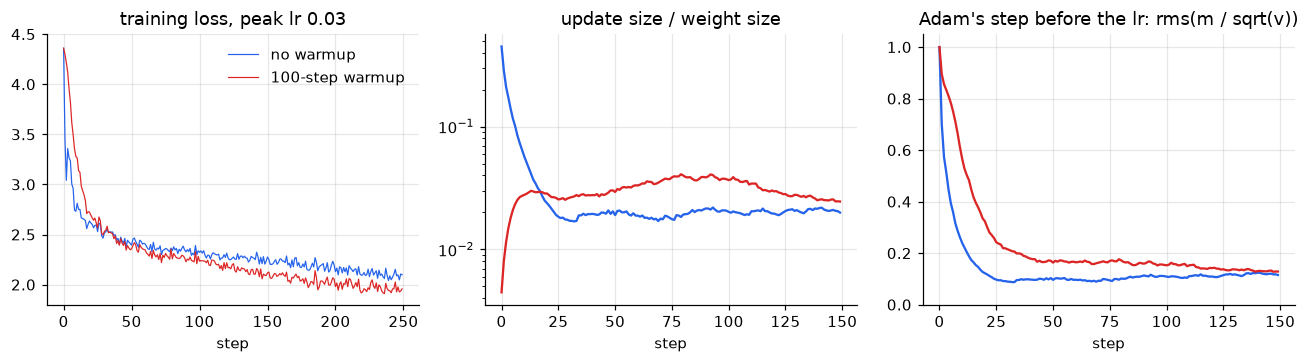

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for (peak, warmup), r in warm_runs.items():
    if peak != 3e-2:
        continue
    label = "no warmup" if warmup == 0 else "100-step warmup"
    axes[0].plot(r["train"], lw=0.8, label=label)
    axes[1].semilogy(r["rel_update"][:150], label=label)
    axes[2].plot(r["adam_ratio"][:150], label=label)
axes[0].set(title="training loss, peak lr 0.03", xlabel="step", ylim=(1.8, 4.5))
axes[1].set(title="update size / weight size", xlabel="step")
axes[2].set(title="Adam's step before the lr: rms(m / sqrt(v))", xlabel="step", ylim=(0, 1.05))
axes[0].legend(frameon=False)
fig.tight_layout()
for (peak, warmup), r in warm_runs.items():
    if peak == 3e-2:
        ru, ar = r["rel_update"], r["adam_ratio"]
        print(f"warmup {warmup:3d}: relative update at step 1 {ru[0]:.3f}, mean over steps 1-10 {np.mean(ru[:10]):.3f}, "
              f"steps 150-250 {np.mean(ru[150:]):.4f}; Adam ratio at step 1 {ar[0]:.2f}, step 10 {ar[9]:.2f}, step 100 {ar[99]:.2f}")

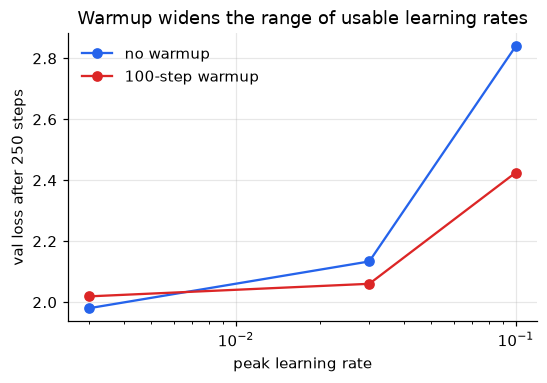

In [9]:
peaks = [3e-3, 3e-2, 1e-1]
fig, ax = plt.subplots(figsize=(5.5, 3.4))
for warmup, label in [(0, "no warmup"), (100, "100-step warmup")]:
    ax.plot(peaks, [warm_runs[(p, warmup)]["val"][-1] for p in peaks], marker="o", label=label)
ax.set(xscale="log", xlabel="peak learning rate", ylabel="val loss after 250 steps",
       title="Warmup widens the range of usable learning rates")
ax.legend(frameon=False);

#### Why it worked: a post-mortem

**Adam's first steps are huge, and warmup shrinks them.** Without warmup, the very first update moved the block weights by 45% of their own norm (relative update 0.448), and the first 10 updates averaged 0.170. With warmup, the first 10 averaged 0.018. After the warmup both runs settle near 0.02. The right panel shows why: Adam's step before the learning rate, the root mean square of `\(\hat m / \sqrt{\hat v}\)`, is exactly 1.00 on step 1 and falls to 0.26 by step 10 and 0.11 by step 100, as gradients from different batches start to disagree. So at a fixed rate, the effective step on update 1 is about 10 times the step on update 100. **[established]** (the algebra is exact; the size of the ratio is our measurement)

**At a high rate, those first steps do damage that does not heal.** At peak 0.1 the run without warmup spiked to a loss of 5.47, worse than the 4.17 of a model that guesses uniformly over the 65 characters, and ended at 2.839 against 2.425 with warmup. At 0.03 the gap was smaller (2.134 against 2.060). Liu et al. (2019) frame the same effect statistically: `\(\hat v\)` is estimated from very few gradients early on, so the adaptive rate `\(1/\sqrt{\hat v}\)` has a large variance; their RAdam optimizer switches off adaptivity until enough samples have accumulated. **[likely]**

**At a moderate rate, warmup did not help here.** At peak 0.003 the run without warmup was better (1.980 against 2.019), simply because 100 of its 250 steps were not spent at a reduced rate. Read the "worst loss" column with care: the warmup runs' worst values are their slow first steps, not spikes. The honest summary of our sweep is that warmup *widens the range of peak rates that work*, which is how Wortsman et al. (2023) describe it in larger models, rather than improving the best run. **[likely]**

**Why Transformers in particular?** Our model is pre-norm (chapter 6), which is much more forgiving. The original Transformer was **Post-LN**: it normalized *after* adding each residual. Xiong et al. (2020) showed that at initialization this makes the gradients of the last layers large, so large early steps break it, and that a Pre-LN Transformer can train with little or no warmup. **[likely]** A third view (Kalra and Barkeshli, 2024) is that warmup lets the network drift into flatter regions of the loss surface, which then tolerate the larger peak rate. **[speculative]** These explanations are not exclusive; all three say that the start of training is when the network is most fragile.

### Step 3 (major): cosine decay, and its rivals at the same budget

#### The idea

Step decay has hand-picked milestones. Loshchilov and Hutter (2016) replaced them with one smooth curve, half a cosine wave from the peak to near zero, in a method called SGDR (they also restarted the cosine several times; the restarts did not stick, the cosine did). Cosine has no milestones to tune, spends a long time at high rates and a long time at low rates, and decays smoothly in between. With a warmup in front, it became the default for GPT-3, Chinchilla, LLaMA and most LLMs.

Its weakness is that the curve is defined by the total number of steps. Hoffmann et al. (2022) found that a cosine cycle set 25% or more longer than the actual run gave a clearly worse model, so the length must be fixed before training starts. If you later want to train longer, the run you have is in the wrong shape. **[established]**

**Warmup-stable-decay** (WSD), popularized by MiniCPM (Hu et al., 2024), keeps the warmup, then holds the rate flat for most of the run, and decays it only over the last 10 to 20% of steps. Hägele et al. (2024) showed it matches cosine at the same budget across many model sizes.

#### Experiment: four schedules, one budget

Constant, step decay (divide by 10 at 50% and 75%), cosine and WSD (linear decay to zero over the last 20%), all with the same 50-step warmup, peak rate 0.01 and 500 steps.

constant final val loss 1.869


step     final val loss 1.843


cosine   final val loss 1.799


wsd      final val loss 1.790


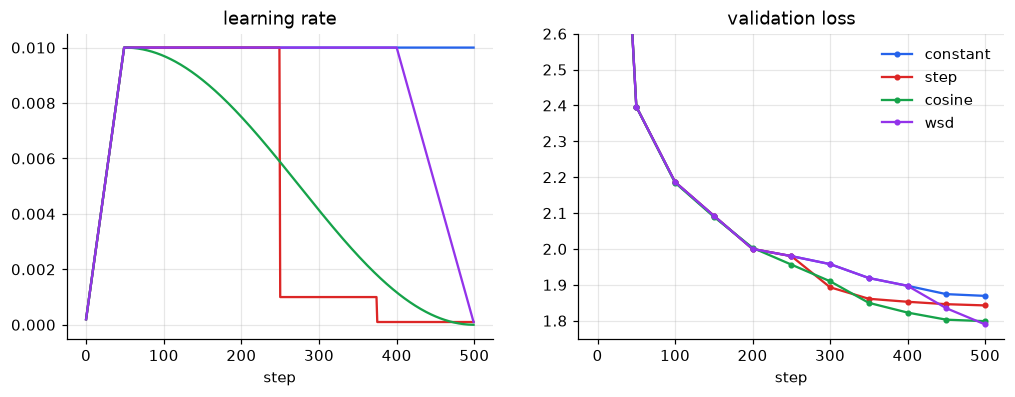

In [10]:
budget, peak = 500, 1e-2
sched_runs = {}
for kind in ["constant", "step", "cosine", "wsd"]:
    save = (200,) if kind == "constant" else ()  # the constant run doubles as WSD's stable phase, for step 4
    sched_runs[kind] = train(make_schedule(kind, peak, budget), budget, save_at=save)
    print(f"{kind:8s} final val loss {sched_runs[kind]['val'][-1]:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
for kind, r in sched_runs.items():
    ax1.plot(r["lr"], label=kind)
    ax2.plot(r["step"], r["val"], marker=".", label=kind)
ax1.set(title="learning rate", xlabel="step")
ax2.set(title="validation loss", xlabel="step", ylim=(1.75, 2.6))
ax2.legend(frameon=False);

In [11]:
print("val loss at step:  " + "  ".join(f"{s:5d}" for s in sched_runs["constant"]["step"][4::2]))
for kind, r in sched_runs.items():
    print(f"{kind:17s}  " + "  ".join(f"{v:.3f}" for v in r["val"][4::2]))

val loss at step:    200    300    400    500
constant           2.000  1.958  1.897  1.869
step               2.000  1.893  1.853  1.843
cosine             2.003  1.910  1.823  1.799
wsd                2.000  1.958  1.897  1.790


#### Why it worked: a post-mortem

**Any decay beats none.** Constant ended at 1.869; every schedule that lowers the rate at the end did better. **[established]**

**Step decay helps less than a smooth decay here.** Its first cut at step 250 gave a sharp drop (1.893 at step 300 against 1.958 for constant), but after the second cut the rate was too small to make further progress, and it ended at 1.843. Its milestones were not tuned for this run, which is exactly the problem that cosine removed. **[likely]**

**WSD lags all the way, then catches up in the decay.** At step 400, WSD is still on the constant curve (1.897) while cosine is at 1.823. Over the final 100 steps WSD drops to 1.790 and finishes slightly ahead of cosine (1.799). Hägele et al. (2024) found the same pattern at scale: WSD matches cosine, and the final cooldown is where its loss falls. **[established]** Across three seeds WSD finished ahead of cosine every time, by 0.006 to 0.026, so the small edge looks real at this scale, though it is far smaller than the gap to the constant and step schedules.

Why does a short decay recover so much? One account: during the stable phase the weights make fast progress along the steep directions of the loss but bounce around in a noise cloud; the decay removes the noise, and the loss drops to the floor it was already "hiding" above. Our noisy quadratic in step 1 behaves exactly this way. **[likely]**

### Step 4 (major): branch a decay off any checkpoint

#### The idea

During WSD's stable phase the schedule does not know when training will end. That means the stable phase is the same run whatever the final length will be. To get a finished model after `\(N\)` steps, take the stable-phase checkpoint at `\(0.8N\)` and run a short decay from there. One long run at a constant rate can produce finished models at many lengths, each for the cost of a short decay. With cosine, each length needs its own run from scratch. This is what made WSD attractive for scaling-law studies, which need models trained for many different lengths (Hägele et al., 2024), and for open-ended pretraining, where the final length is decided late. **[established]**

#### Experiment: a 250-step model for the price of 50 steps

We take the constant-rate run from step 3, which is exactly WSD's stable phase, load its checkpoint at step 200, and decay the rate to zero over 50 steps. We compare it with a cosine schedule planned for 250 steps from the start, and with the 500-step cosine run stopped early at step 250.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">The branch trains for only 50 steps after the checkpoint. Will its loss at step 250 beat a cosine schedule that was planned for 250 steps from the start?</p><details><summary>Show what happened</summary><p>Yes: the branch reaches 1.925 and the 250-step cosine run 1.956. The constant-rate checkpoint it started from was at about 2.00.</p></details></div>

after 250 steps: constant 1.980, cosine planned for 250 1.956, WSD branch decayed from step 200 1.925
after 500 steps: cosine 1.799, WSD 1.790
the 500-step cosine run, stopped early at step 250: 1.956


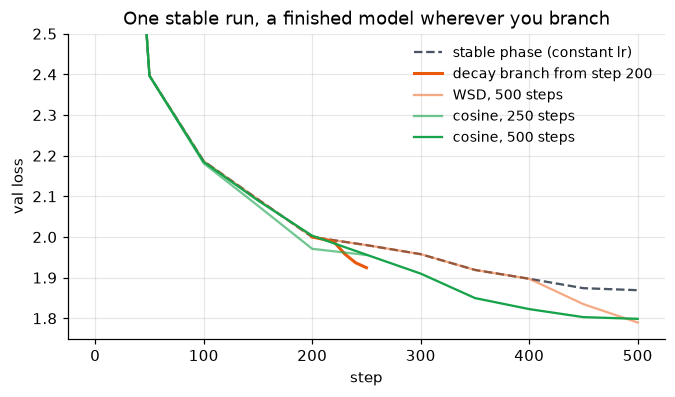

In [12]:
short = 250
ckpt = sched_runs["constant"]["ckpt"][200]  # the constant run at step 200: WSD's stable phase so far
branch = train(make_schedule("wsd", peak, short), short, resume=ckpt, eval_every=10)
cos_short = train(make_schedule("cosine", peak, short), short)
const_250 = sched_runs["constant"]["val"][sched_runs["constant"]["step"].index(short)]

print(f"after {short} steps: constant {const_250:.3f}, cosine planned for {short} {cos_short['val'][-1]:.3f}, "
      f"WSD branch decayed from step 200 {branch['val'][-1]:.3f}")
print(f"after {budget} steps: cosine {sched_runs['cosine']['val'][-1]:.3f}, WSD {sched_runs['wsd']['val'][-1]:.3f}")
cos500_at_250 = sched_runs["cosine"]["val"][sched_runs["cosine"]["step"].index(short)]
print(f"the 500-step cosine run, stopped early at step {short}: {cos500_at_250:.3f}")

fig, ax = plt.subplots(figsize=(7, 3.6))
c = sched_runs["constant"]
ax.plot(c["step"], c["val"], color="#4b5563", ls="--", label="stable phase (constant lr)")
ax.plot(branch["step"], branch["val"], color="#ea580c", lw=2, label="decay branch from step 200")
ax.plot(sched_runs["wsd"]["step"], sched_runs["wsd"]["val"], color="#ea580c", alpha=0.5, label="WSD, 500 steps")
ax.plot(cos_short["step"], cos_short["val"], color="#16a34a", alpha=0.6, label="cosine, 250 steps")
ax.plot(sched_runs["cosine"]["step"], sched_runs["cosine"]["val"], color="#16a34a", label="cosine, 500 steps")
ax.set(xlabel="step", ylabel="val loss", ylim=(1.75, 2.5), title="One stable run, a finished model wherever you branch")
ax.legend(frameon=False, fontsize=9);

#### Why it worked: a post-mortem

**The branch is the best 250-step model, at a fraction of the cost.** The constant run at step 250 was at 1.980. The 50-step decay branched off its step-200 checkpoint reached 1.925, better than the cosine schedule planned for 250 steps from the start (1.956), and better than the 500-step cosine run stopped at step 250 (also 1.956). The cosine-250 model cost 250 new steps; the branch cost 50. **[established]**; the branch beat the cosine-250 run in all three seeds we ran, by 0.031 to 0.035.

**Where this matters.** A scaling-law study needs finished models at many lengths. With cosine, that means one full run per length. With WSD, it means one stable run plus a short decay per length (Hägele et al., 2024). The same property lets a lab keep pretraining a model and decide late when to stop, or resume the stable phase with more data. MiniCPM (Hu et al., 2024) used it for exactly these reasons, and DeepSeek LLM (2024) used a multi-step schedule with the same motivation. **[established]**

### Step 5 (minor): schedule-free

#### The idea

WSD still has a decay phase, so you must decide when to stop before you have a usable model. Defazio et al. (2024) asked whether the decay can be removed altogether. Their **schedule-free** method keeps the rate constant after warmup and instead keeps a running average of the weights. Averaging does the job a decay does: it cancels the noise in the last stretch of iterates, so the average sits closer to the minimum than any single iterate. The trick that makes it work in practice is to compute the gradient at a point between the current iterate and the average, rather than at either one. Every weight's average is a usable, finished model at every step.

The implementation is short. It replaces the optimizer, not the schedule.

In [13]:
class ScheduleFreeAdamW(torch.optim.Optimizer):
    """Schedule-free AdamW (Defazio et al., 2024), written for clarity.

    Each parameter keeps two sequences: z, a plain Adam iterate with a constant learning rate,
    and x, a running average of z. Gradients are taken at y, a point between them.
    The model's parameters hold y during training; call .eval_mode() to swap in x for evaluation.
    """

    def __init__(self, params, lr=1e-2, betas=(0.9, 0.95), weight_decay=0.1, warmup=50, eps=1e-8):
        super().__init__(params, dict(lr=lr, betas=betas, weight_decay=weight_decay, warmup=warmup, eps=eps))
        self.t, self.weight_sum = 0, 0.0

    @torch.no_grad()
    def step(self):
        self.t += 1
        for g in self.param_groups:
            beta1, beta2 = g["betas"]
            lr = g["lr"] * min(1.0, self.t / g["warmup"])  # warmup is still used
            self.weight_sum += lr ** 2
            c = lr ** 2 / self.weight_sum  # weight of the newest z in the average x
            for p in g["params"]:
                if p.grad is None:
                    continue
                st = self.state[p]
                if not st:
                    st["z"], st["x"], st["v"] = p.clone(), p.clone(), torch.zeros_like(p)
                z, x, v = st["z"], st["x"], st["v"]
                v.mul_(beta2).addcmul_(p.grad, p.grad, value=1 - beta2)
                denom = (v / (1 - beta2 ** self.t)).sqrt().add_(g["eps"])
                z.sub_(lr * (p.grad / denom + g["weight_decay"] * p))  # gradient and decay taken at y = p
                x.lerp_(z, c)  # x <- (1 - c) x + c z
                p.copy_(x.lerp(z, 1 - beta1))  # y = beta1 x + (1 - beta1) z

    @torch.no_grad()
    def eval_mode(self, on=True):
        for g in self.param_groups:
            for p in g["params"]:
                if self.state[p]:
                    st = self.state[p]
                    p.copy_(st["x"] if on else st["x"].lerp(st["z"], 1 - g["betas"][0]))

In [14]:
torch.manual_seed(0)
model = TransformerLM(tok.vocab_size, dim=64, n_layers=4, n_heads=4)
opt = ScheduleFreeAdamW(model.parameters(), lr=peak)
gen = torch.Generator().manual_seed(0)
sf = {"step": [], "val": []}
for s in range(budget + 1):
    if s % 50 == 0:
        opt.eval_mode(True)  # evaluate the averaged weights x
        sf["step"].append(s)
        sf["val"].append(val_loss(model))
        opt.eval_mode(False)
    if s == budget:
        break
    x, y = mlexp.get_batch(train_ids, 32, 64, gen)
    _, loss = model(x, y)
    opt.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()

print("val loss at step:   " + "  ".join(f"{s:5d}" for s in sf["step"][4::2]))
print("schedule-free      " + "  ".join(f"{v:.3f}" for v in sf["val"][4::2]))
for kind in ["constant", "cosine", "wsd"]:
    print(f"{kind:17s}  " + "  ".join(f"{v:.3f}" for v in sched_runs[kind]["val"][4::2]))
print(f"\nnotebook compute time so far: {time.time() - t_start:.0f} s")

val loss at step:     200    300    400    500
schedule-free      1.955  1.880  1.815  1.777
constant           2.000  1.958  1.897  1.869
cosine             2.003  1.910  1.823  1.799
wsd                2.000  1.958  1.897  1.790

notebook compute time so far: 510 s


#### Why it worked: a post-mortem

**Schedule-free matched the best schedule without knowing when training would end.** In this run it finished at 1.777, ahead of WSD (1.790) and cosine (1.799), at the same peak rate and without tuning. Across three seeds it tied with WSD (1.786 against 1.787 on average; ahead in one seed, behind in two) and beat or matched cosine in each. Where it reliably wins is along the way: it was ahead of every other schedule at step 200 in all three seeds (1.955 against 2.000 here), because its averaged weights are always partly "decayed", whereas the other schedules only reach their best loss at the end. **[likely]** at this scale; we ran a tiny model with three seeds.

**What it does and does not remove.** It removes the decay, and with it the need to know the training length. It does not remove warmup, which our implementation still uses, or the peak rate. Defazio et al. (2024) report results that match or beat tuned cosine schedules on many problems; how it behaves at the scale of frontier LLMs, where WSD is now common, is less settled. **[likely]**

**The common thread.** Step decay, cosine, WSD and schedule-free all solve the same problem from step 1: noisy gradients keep the weights in a cloud around the minimum. Decaying the rate shrinks the cloud; averaging the weights finds its centre. Warmup solves a different problem, at the other end of training: Adam's first steps are too large for a freshly initialized Transformer.

## Across three seeds

The numbers on this page come from one run, seed 0. We reran the whole notebook twice more with every random seed shifted by 1 and by 2, which changes the initial weights, the batches and the evaluation samples (the `Seed runs` workflow in the repository does this for any chapter). A gap between two runs means something only when it is clearly larger than their spread.

| Run | This page (seed 0) | Mean ± sd, 3 seeds | Seeds 0 / 1 / 2 |
| --- | --- | --- | --- |
| Toy: constant lr 0.5, final loss | 2.5738 | 2.9349 ± 0.4070 | 2.5738 / 2.8549 / 3.3759 |
| Toy: constant lr 0.05 | 0.2516 | 0.2146 ± 0.0524 | 0.2516 / 0.2375 / 0.1546 |
| Toy: step decay | 0.0960 | 0.1965 ± 0.0873 | 0.0960 / 0.2405 / 0.2530 |
| Peak 0.003, no warmup | 1.980 | 1.982 ± 0.011 | 1.980 / 1.972 / 1.993 |
| Peak 0.003, warmup 100 | 2.019 | 2.016 ± 0.022 | 2.019 / 1.992 / 2.036 |
| Peak 0.1, no warmup | 2.839 | 2.862 ± 0.076 | 2.839 / 2.800 / 2.947 |
| Peak 0.1, warmup 100 | 2.425 | 2.679 ± 0.233 | 2.425 / 2.729 / 2.883 |
| Constant | 1.869 | 1.876 ± 0.008 | 1.869 / 1.875 / 1.884 |
| Step | 1.843 | 1.846 ± 0.003 | 1.843 / 1.849 / 1.846 |
| Cosine | 1.799 | 1.800 ± 0.004 | 1.799 / 1.805 / 1.797 |
| WSD | 1.790 | 1.787 ± 0.007 | 1.790 / 1.779 / 1.791 |
| WSD branched at step 200, at 250 steps | 1.925 | 1.924 ± 0.005 | 1.925 / 1.929 / 1.919 |
| Cosine planned for 250 steps | 1.956 | 1.957 ± 0.007 | 1.956 / 1.964 / 1.950 |
| Schedule-free | 1.777 | 1.786 ± 0.010 | 1.777 / 1.785 / 1.797 |
| Schedule-free at step 200 | 1.955 | 1.953 ± 0.016 | 1.955 / 1.936 / 1.968 |

The warmup results and the schedule ranking (constant, step, cosine, WSD) held in every seed, and so did the WSD branch. Two claims needed softening: step decay's low final loss on the toy problem appeared in one seed only, and schedule-free ties WSD at the end rather than beating it, though it leads at step 200 every time.

## Recap

<div class="mlx-box mlx-box--objectives"><p class="mlx-box__label">Recap</p><p>You should now be able to:</p><ol><li>Explain why a constant learning rate leaves the loss on a noise floor, and why decaying it lowers that floor.</li><li>Show why Adam's first steps are large, and how warmup and pre-norm reduce the damage they do.</li><li>Implement constant, step, cosine and warmup-stable-decay schedules, and compare them at one budget.</li><li>Branch a decay off a WSD checkpoint to get a finished model at a new length.</li></ol></div>

<div class="mlx-box mlx-box--check"><p class="mlx-box__label">Check your understanding</p><details><summary>The loss of a run at a constant learning rate stops improving. You halve the rate and the loss drops at once. Why?</summary><p>The weights were bouncing around the minimum in a cloud whose size grows with the learning rate, because every gradient is noisy. Halving the rate shrinks the cloud, so the average loss falls to a lower floor straight away.</p></details><details><summary>Why is Adam's step on update 1 as large as the learning rate in every coordinate, and why is it smaller later?</summary><p>After one update, \(\hat m = g\) and \(\sqrt{\hat v} = |g|\), so the ratio is the sign of the gradient. Later, \(\hat m\) averages gradients that partly cancel while \(\hat v\) keeps their full size, so the ratio is well below 1.</p></details><details><summary>You trained with WSD for 8,000 steps and saved checkpoints. How do you get a finished model for a 5,000-step budget, and what would cosine need?</summary><p>Load the stable-phase checkpoint at 4,000 steps and decay for 1,000 steps. With cosine, the curve depends on the total length, so you would need a new run of 5,000 steps from scratch.</p></details></div>

## Further reading

- Loshchilov and Hutter, 2016, [SGDR: Stochastic Gradient Descent with Warm Restarts](https://arxiv.org/abs/1608.03983): cosine annealing.
- Goyal et al., 2017, [Accurate, Large Minibatch SGD: Training ImageNet in 1 Hour](https://arxiv.org/abs/1706.02677): linear warmup.
- Vaswani et al., 2017, [Attention Is All You Need](https://arxiv.org/abs/1706.03762): warmup followed by inverse square-root decay.
- Liu et al., 2019, [On the Variance of the Adaptive Learning Rate and Beyond](https://arxiv.org/abs/1908.03265): RAdam, warmup as a fix for Adam's early statistics.
- Xiong et al., 2020, [On Layer Normalization in the Transformer Architecture](https://arxiv.org/abs/2002.04745): why Post-LN needs warmup and Pre-LN much less.
- Hu et al., 2024, [MiniCPM: Unveiling the Potential of Small Language Models with Scalable Training Strategies](https://arxiv.org/abs/2404.06395): warmup-stable-decay.
- Hägele et al., 2024, [Scaling Laws and Compute-Optimal Training Beyond Fixed Training Durations](https://arxiv.org/abs/2405.18392): WSD matches cosine; cooldowns from checkpoints.
- Defazio et al., 2024, [The Road Less Scheduled](https://arxiv.org/abs/2405.15682): schedule-free optimization.
- Hoffmann et al., 2022, [Training Compute-Optimal Large Language Models](https://arxiv.org/abs/2203.15556).
- Bergsma et al., 2025, [Straight to Zero: Why Linearly Decaying the Learning Rate to Zero Works Best for LLMs](https://arxiv.org/abs/2502.15938).
- Izmailov et al., 2018, [Averaging Weights Leads to Wider Optima and Better Generalization](https://arxiv.org/abs/1803.05407): SWA.
- Kasimbeg et al., 2025, [Accelerating neural network training: An analysis of the AlgoPerf competition](https://arxiv.org/abs/2502.15015).